In [1]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from inference_models import ResNet18, ResNet34, ResNet50, ResNet101
from inference_models import MobilenetV2, MobilenetV3Small, MobilenetV3Large
from inference_models import EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, EfficientNetB4

In [2]:
def pixelate_image(image, pixel_size):
    small = image.resize((image.width // pixel_size, image.height // pixel_size))
    pixelated = small.resize(image.size, Image.Resampling.NEAREST)
    return pixelated

In [3]:
route_images_test = Path("../results/test_images")
route_images_test.mkdir(parents=True, exist_ok=True)

In [4]:
models = [
    ResNet18,
    ResNet34,
    ResNet50,
    ResNet101,
    MobilenetV2,
    MobilenetV3Small,
    MobilenetV3Large,
    EfficientNetB0,
    EfficientNetB1,
    EfficientNetB2,
    EfficientNetB3,
    EfficientNetB4
]

In [5]:
def test_image(image, pixel_size):
    route_test_image = Path("../results/external_test_images")

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.flatten()

    for i in range(len(models)):
        pred_model = models[i](route_test_image / image)
        display_img, pred_emotion, architectural_name = pred_model
        image_pixelate = pixelate_image(display_img, pixel_size)

        axes[i].imshow(image_pixelate)
        axes[i].set_title(f"{architectural_name}\n{pred_emotion}")
        axes[i].axis("off")

    for i in range(len(models), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(route_images_test / f"Test_{Path(image).stem}.png", dpi=300, bbox_inches="tight")
    plt.show()

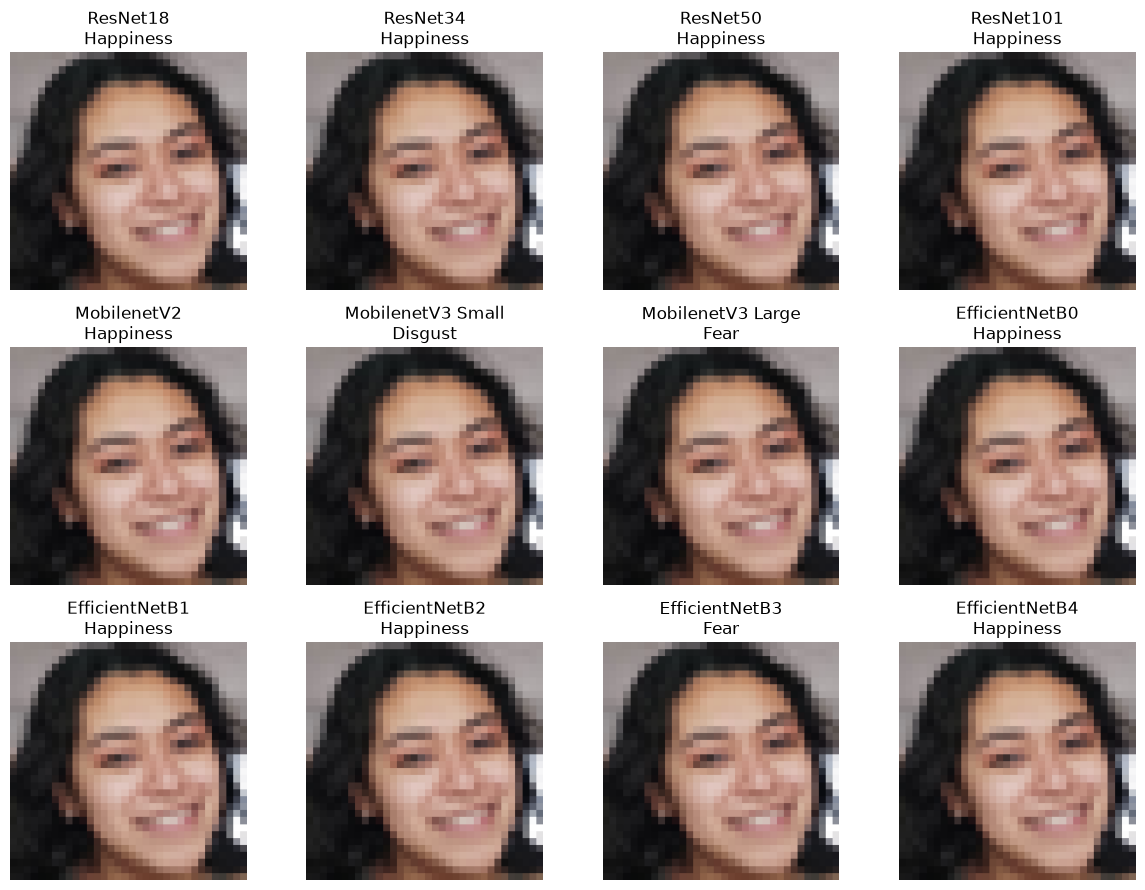

In [6]:
test_image("Example_1.jpg", 10)

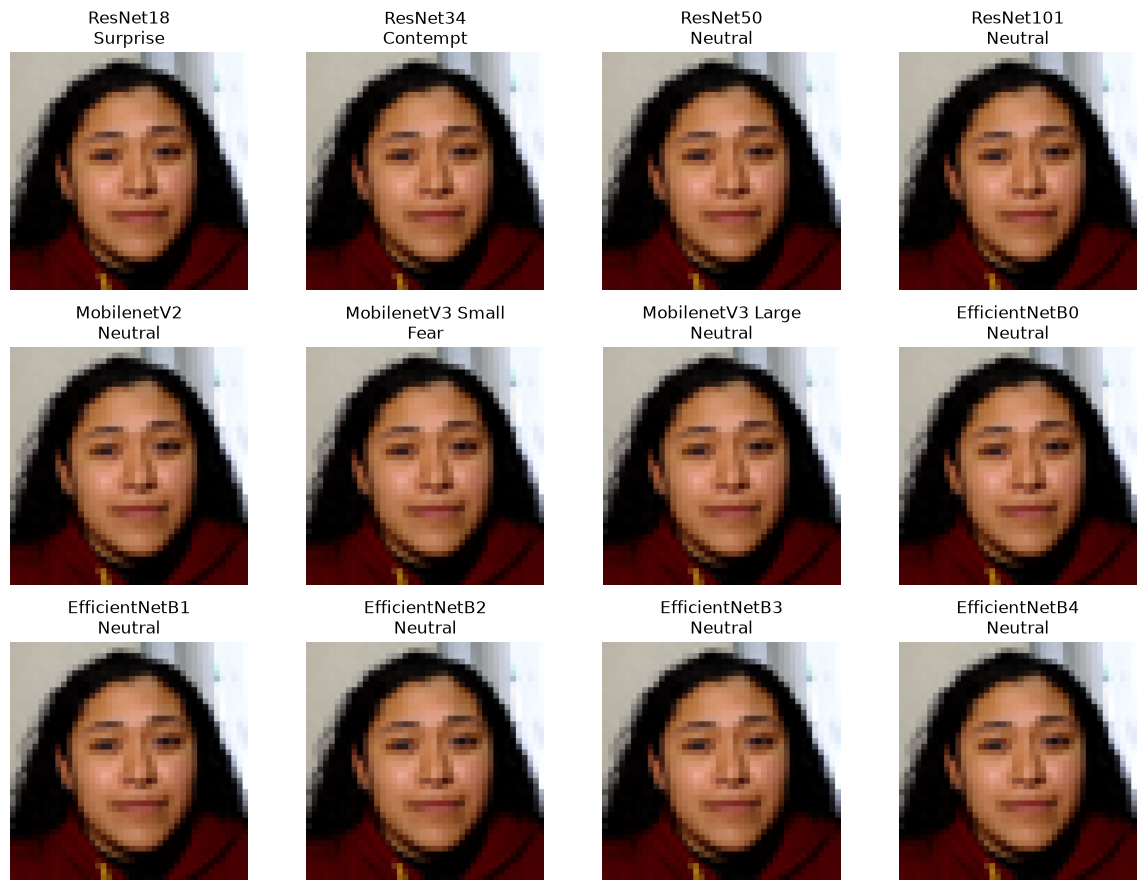

In [7]:
test_image("Example_2.jpg", 15)

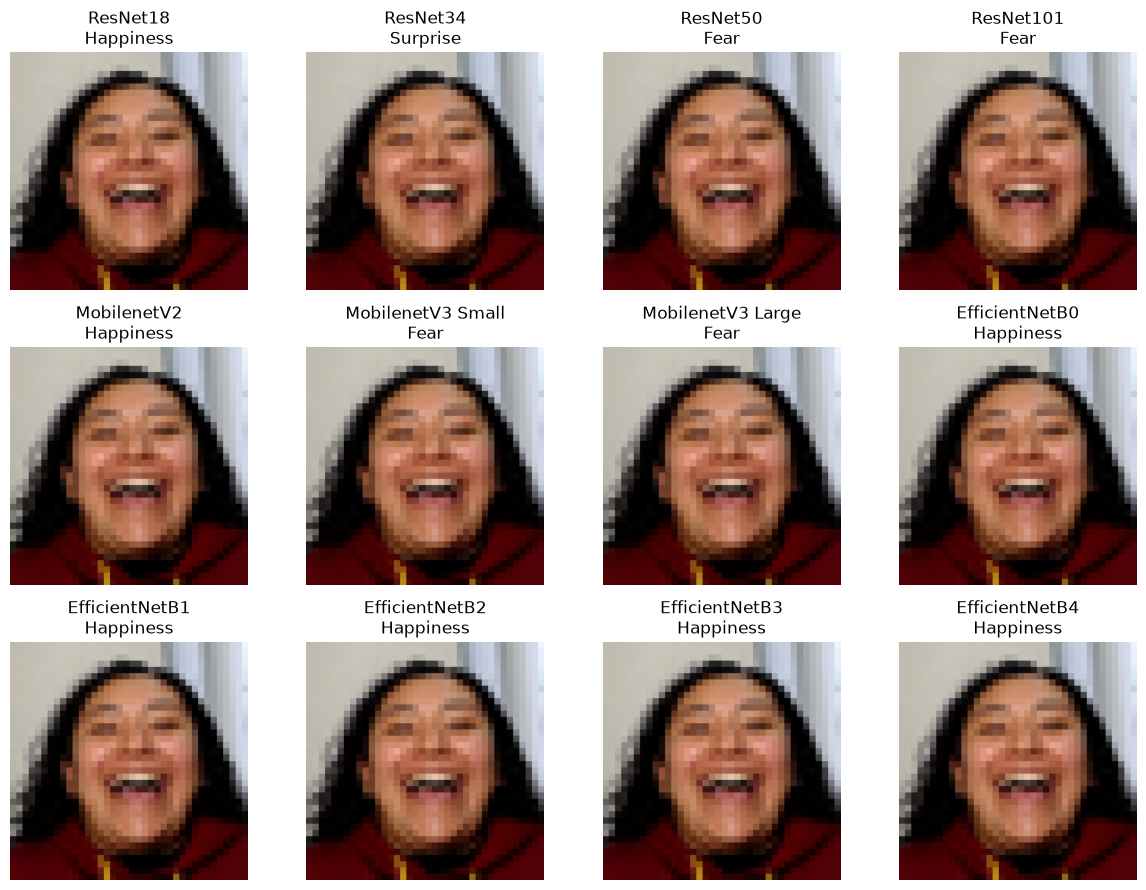

In [8]:
test_image("Example_3.jpg", 15)

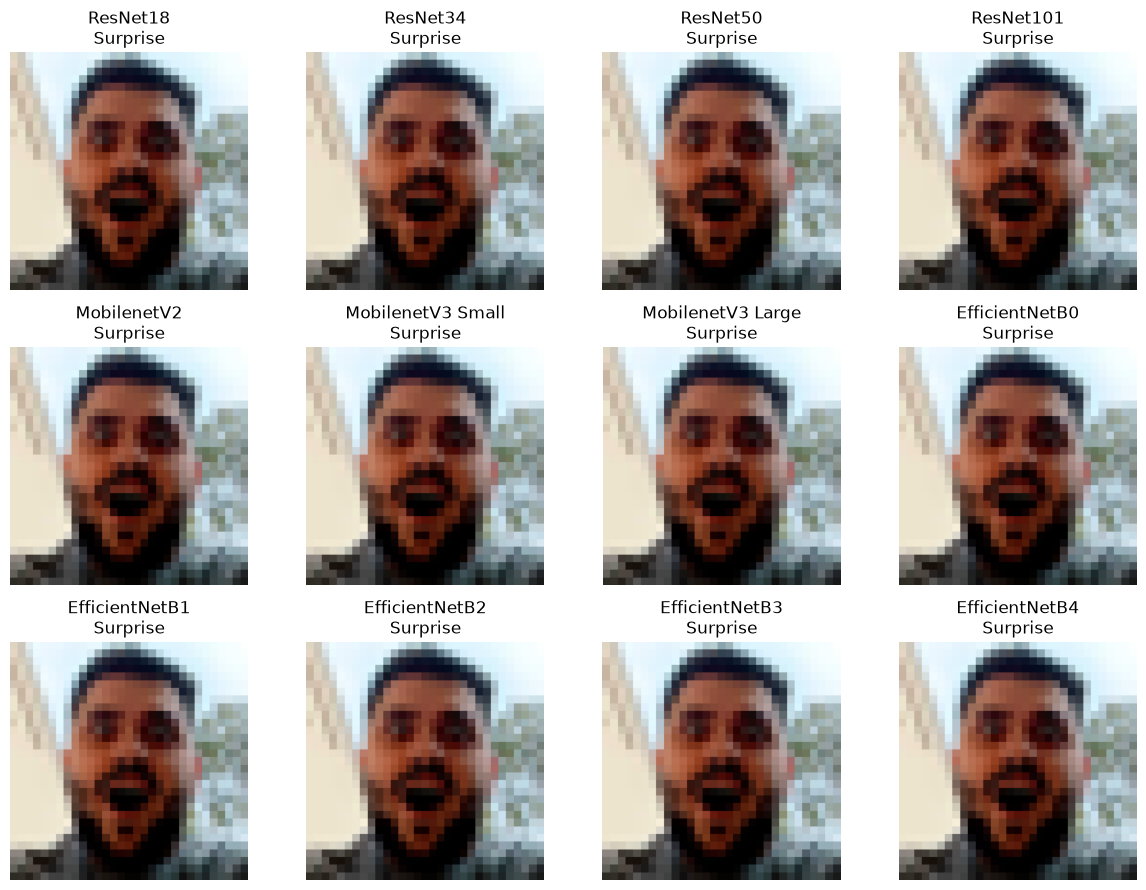

In [9]:
test_image("Example_4.jpeg", 15)

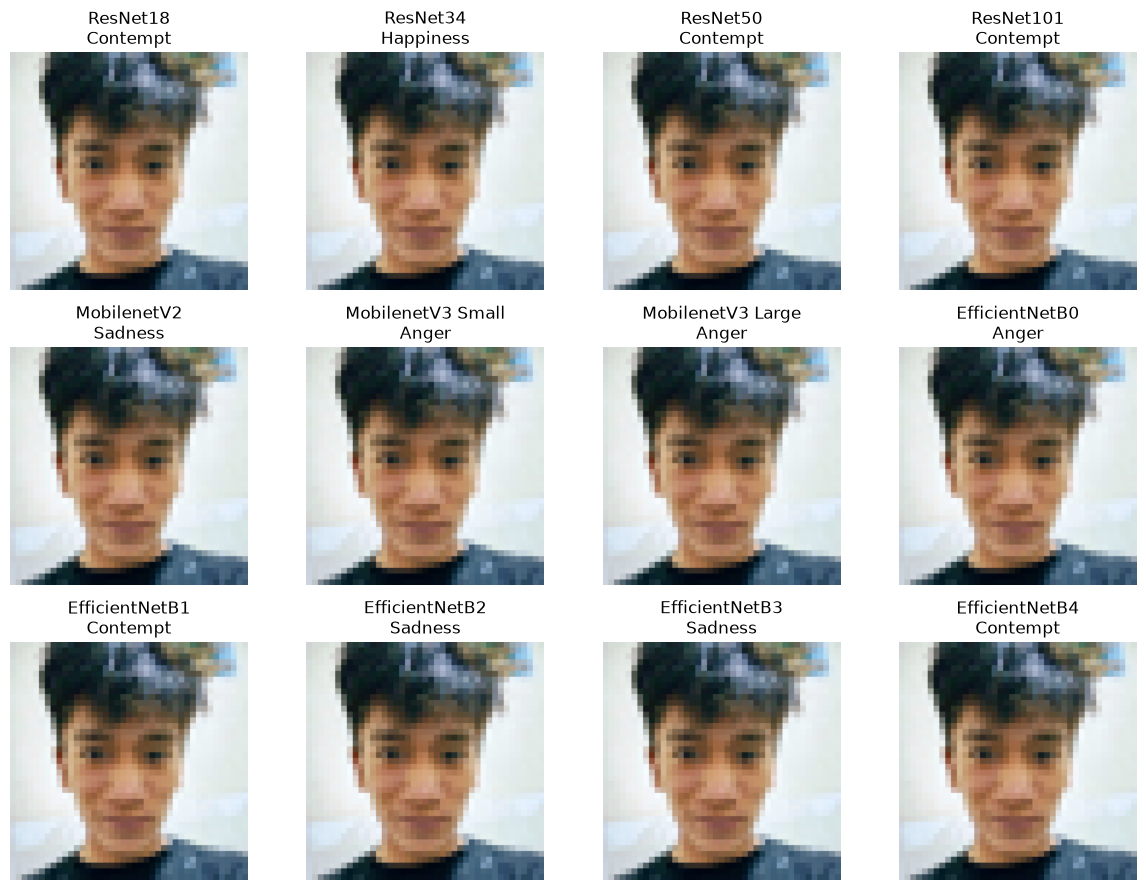

In [10]:
test_image("Example_5.jpeg", 25)